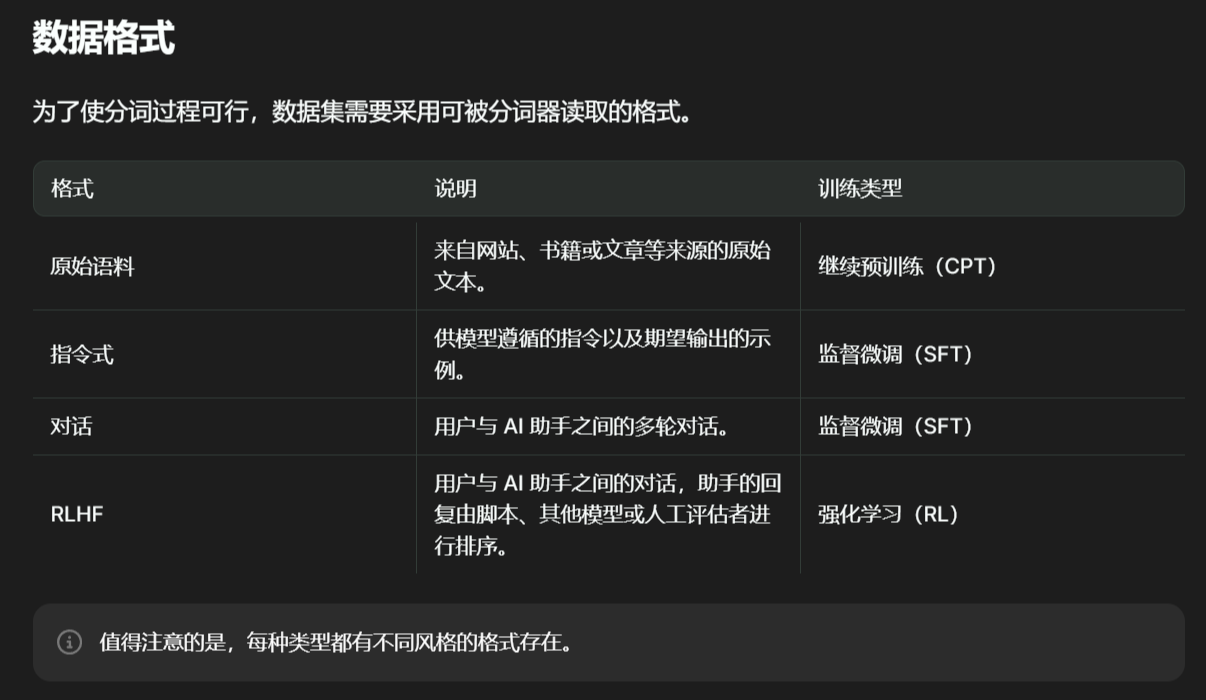

In [ ]:
# instruction  只要是指令类型一般都用alpaca
[
  {
    "instruction": "将下面的句子翻译成英文。",
    "input": "今天天气真好，适合出去散步。",
    "output": "The weather is really nice today, suitable for going out for a walk."
  },
  {
    "instruction": "列出三种常见的可再生能源。",
    "input": "",
    "output": "1. 太阳能\n2. 风能\n3. 水能"
  },
  {
    "instruction": "给这篇文章起一个标题。",
    "input": "人工智能正在迅速改变医疗行业，从诊断到治疗...",
    "output": "人工智能如何重塑医疗行业的未来"
  }
]

In [ ]:
# 继续预训练CFT
"text": "培根意大利面（Pasta carbonara）是一道传统的罗马面食。酱汁由生鸡蛋与磨碎的佩科里诺·罗曼诺（Pecorino Romano）奶酪和黑胡椒混合而成。热意面随后与酥脆的猪颊肉（guanciale，腌制猪颊）和蛋液混合，利用残余热量形成奶油状酱汁。尽管普遍认为如此，正宗的卡博纳拉从不含奶油或大蒜。这道菜很可能起源于20世纪中期的罗马，但其确切起源仍有争议……"

In [ ]:
# shareGPT
{
  "conversations": [
    {
      "from": "human",
      "value": "你能帮我做培根意大利面吗？",
    },
    {
      "from": "gpt",
      "value": "你想要传统的罗马食谱，还是更简单的版本？",
    },
    {
      "from": "human",
      "value": "请给我传统版本",
    },
    {
      "from": "gpt",
      "value": "正宗的罗马卡博纳拉只使用少量配料：意面、猪颊肉、鸡蛋、佩科里诺·罗曼诺和黑胡椒。你想要详细的食谱吗？",
    }
  ]
}

In [ ]:
# OpenAI 的 ChatML 格式，也是 Hugging Face 的默认格式
{
    "messages": [
        {"role": "user", "content": "1+1 等于多少？"},
        {"role": "assistant", "content": "是 2！"},
    ]
}

# 在unsloth中应用聊天模板

In [ ]:
# 检查unsloth当前支持哪些模板  不支持也有其他方案 https://www.yuque.com/lucas_jl/gc7zax/vf8hkukmvgy6yi9g#pKhjb
from unsloth.chat_templates import CHAT_TEMPLATES
print(list(CHAT_TEMPLATES.keys()))

['unsloth', 'zephyr', 'chatml', 'mistral', 'llama', 'vicuna', 'vicuna_old', 'vicuna old', 'alpaca', 'gemma', 'gemma_chatml', 'gemma2', 'gemma2_chatml', 'llama-3', 'llama3', 'phi-3', 'phi-35', 'phi-3.5', 'llama-3.1', 'llama-31', 'llama-3.2', 'llama-3.3', 'llama-32', 'llama-33', 'qwen-2.5', 'qwen-25', 'qwen25', 'qwen2.5', 'phi-4', 'gemma-3', 'gemma3', 'qwen-3', 'qwen3', 'gemma-3n', 'gemma3n', 'gpt-oss', 'gptoss', 'qwen3-instruct', 'qwen3-thinking', 'lfm-2', 'starling', 'yi-chat']
dict_keys(['unsloth', 'zephyr', 'chatml', 'mistral', 'llama', 'vicuna', 'vicuna_old', 'vicuna old', 'alpaca', 'gemma', 'gemma_chatml', 'gemma2', 'gemma2_chatml', 'llama-3', 'llama3', 'phi-3', 'phi-35', 'phi-3.5', 'llama-3.1', 'llama-31', 'llama-3.2', 'llama-3.3', 'llama-32', 'llama-33', 'qwen-2.5', 'qwen-25', 'qwen25', 'qwen2.5', 'phi-4', 'gemma-3', 'gemma3', 'qwen-3', 'qwen3', 'gemma-3n', 'gemma3n', 'gpt-oss', 'gptoss', 'qwen3-instruct', 'qwen3-thinking', 'lfm-2', 'starling', 'yi-chat'])


In [ ]:
# 将正确的聊天模板应用到你的分词器
from unsloth.chat_templates import get_chat_template
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-9b-it")
tokenizer = get_chat_template(
    tokenizer,
    chat_template="gemma",
)

Unsloth: Will map <end_of_turn> to EOS = <eos>.


In [13]:
# 定义你的格式化函数 该函数遍历你的数据集，将你定义的聊天模板应用到每个样本上
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
   return { "text" : texts, }

In [15]:
# 导入并加载数据集
from datasets import load_dataset
dataset = load_dataset("unsloth/alpaca-cleaned", split = "train")

# 使用 map 方法将格式化函数应用到数据集
dataset = dataset.map(formatting_prompts_func, batched = True,)

d:\anaconda3\envs\unsloth_lab\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\libra\.cache\huggingface\hub\datasets--unsloth--alpaca-cleaned. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 51760 examples [00:00, 223874.07 examples/s]
Map:   0%|          | 0/51760 [00:00<?, ? exa

KeyError: 'conversations'

In [ ]:
# ShareGPT 格式且带有 "from"/"value" 键而不是 ChatML 的 "role"/"content" 格式，你可以先使用 standardize_sharegpt 函数将其转换。修改后的代码如下
# 导入数据集
# from datasets import load_dataset
# dataset = load_dataset("mlabonne/FineTome-100k", split = "train")

# # 如有必要，将数据集转换为 "role"/"content" 格式
# from unsloth.chat_templates import standardize_sharegpt
# dataset = standardize_sharegpt(dataset)

# # 使用 map 方法将格式化函数应用到数据集
# dataset = dataset.map(formatting_prompts_func, batched = True,)

In [ ]:
from unsloth import FastLanguageModel

# 1. 直接加载模型和 tokenizer
# Unsloth 会自动检测模型类型 (如 Gemma, Llama, Qwen 等)
# 并自动应用正确的 chat_template 到返回的 tokenizer 上
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="google/gemma-2-9b-it",
    max_seq_length=2048,      # 可选：设置最大长度
    dtype=None,               # 可选：自动选择精度 (None 代表自动)
    load_in_4bit=True,        # 可选：是否使用 4bit 量化
)

# 2. 直接使用 tokenizer.apply_chat_template
# 此时 tokenizer 已经内置了正确的模板，无需额外步骤
messages = [
    {"role": "user", "content": "你好，Gemma！请介绍一下你自己。"}
]

# 直接调用即可，不需要再包一层 get_chat_template
text = tokenizer.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True
)

print(text)